[0.00s]  Groove spacing: 7.91 px → Estimated depth: 0.16 cm


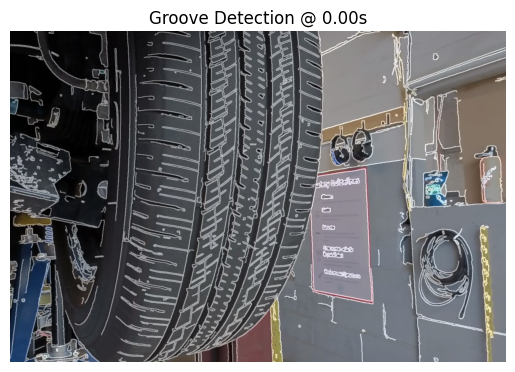

[0.50s]  Groove spacing: 8.73 px → Estimated depth: 0.17 cm


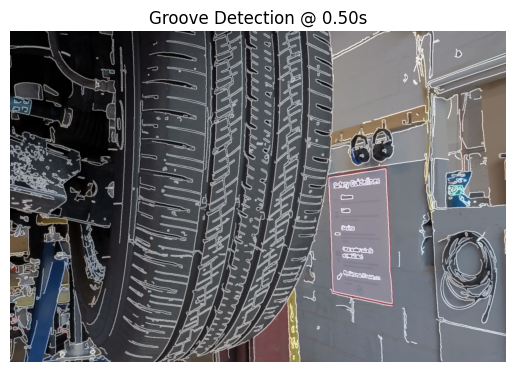

[1.00s]  Groove spacing: 9.11 px → Estimated depth: 0.18 cm


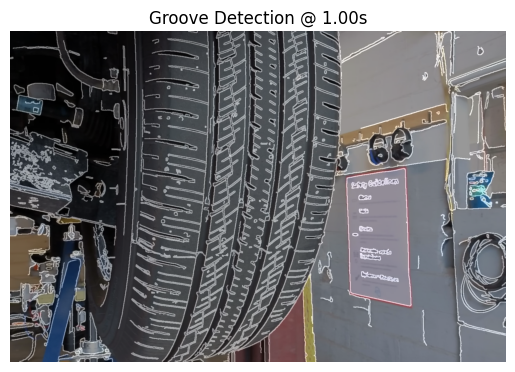

[1.50s]  Groove spacing: 7.16 px → Estimated depth: 0.14 cm


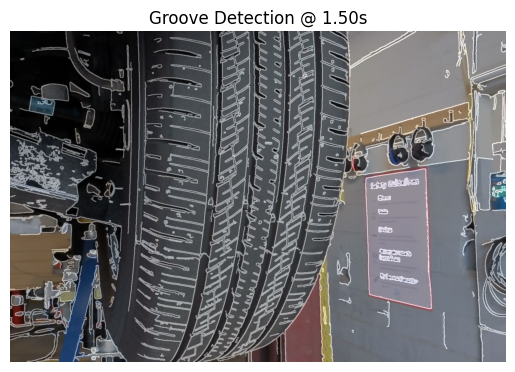

[2.00s]  Groove spacing: 7.46 px → Estimated depth: 0.15 cm


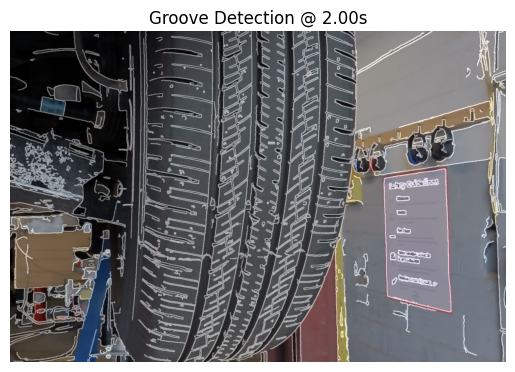

[2.50s]  Groove spacing: 4.64 px → Estimated depth: 0.09 cm


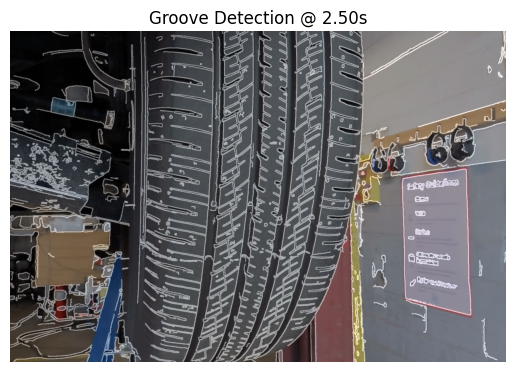

[3.00s]  Groove spacing: 4.82 px → Estimated depth: 0.10 cm


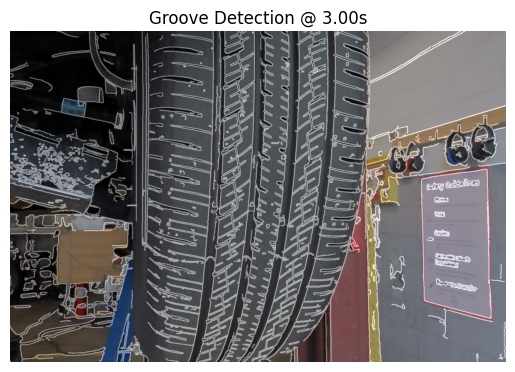

[3.50s]  Groove spacing: 4.84 px → Estimated depth: 0.10 cm


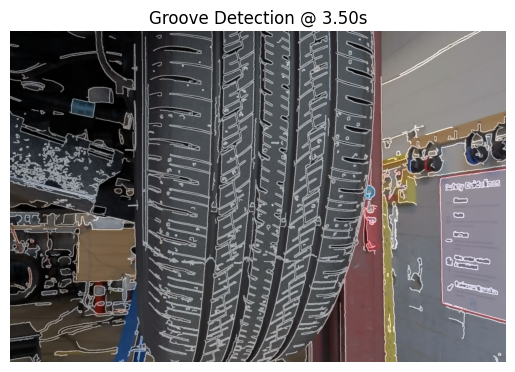

[4.00s]  Groove spacing: 6.34 px → Estimated depth: 0.13 cm


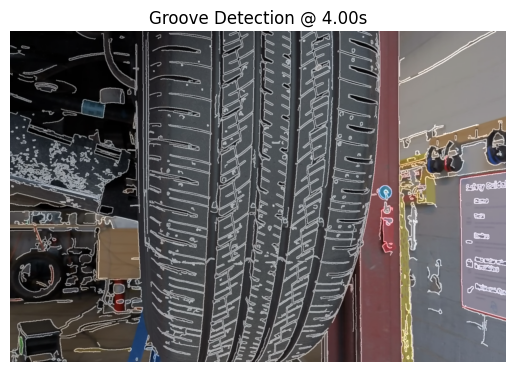

[4.50s]  Groove spacing: 7.04 px → Estimated depth: 0.14 cm


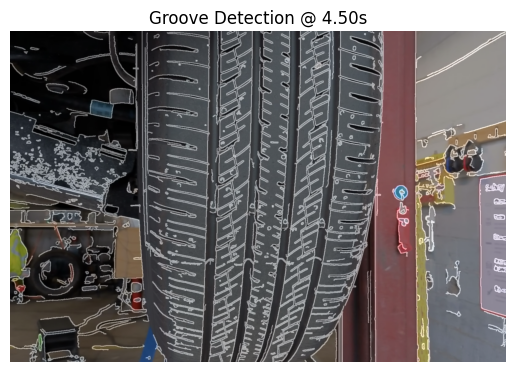

[5.00s]  Groove spacing: 7.48 px → Estimated depth: 0.15 cm


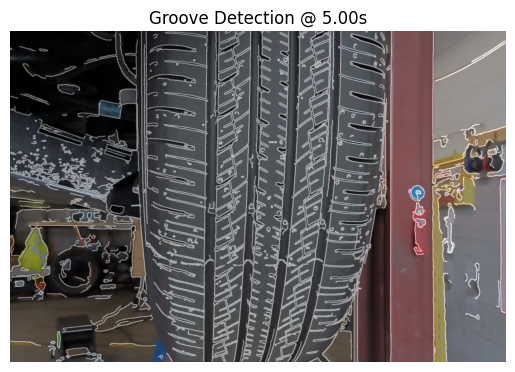

[5.50s]  Groove spacing: 6.35 px → Estimated depth: 0.13 cm


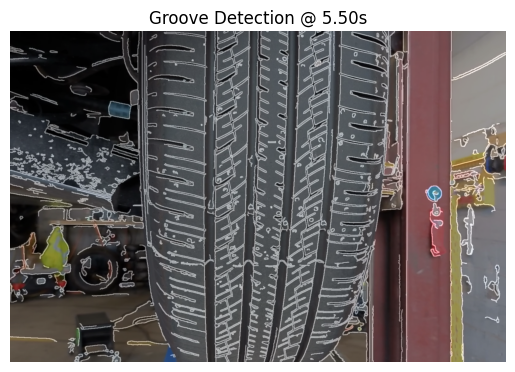

[6.00s]  Groove spacing: 6.78 px → Estimated depth: 0.14 cm


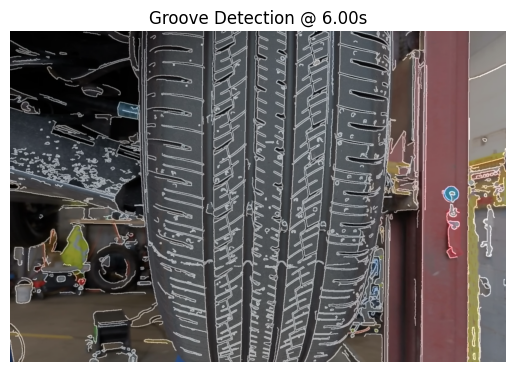

[6.50s]  Groove spacing: 7.08 px → Estimated depth: 0.14 cm


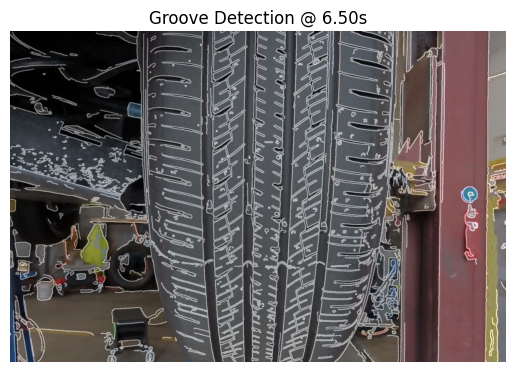

[7.00s]  Groove spacing: 6.22 px → Estimated depth: 0.12 cm


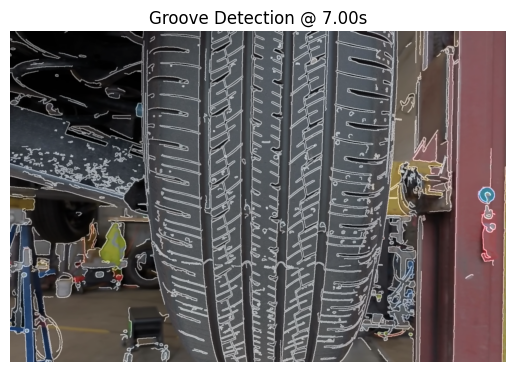

[7.50s]  Groove spacing: 6.62 px → Estimated depth: 0.13 cm


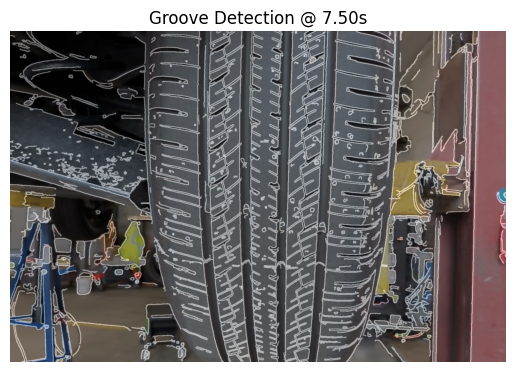

[8.00s]  Groove spacing: 6.98 px → Estimated depth: 0.14 cm


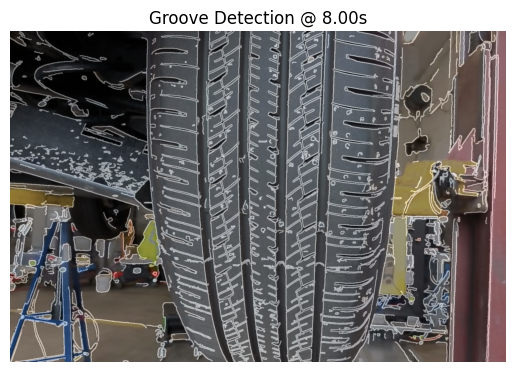

[8.50s]  Groove spacing: 7.28 px → Estimated depth: 0.15 cm


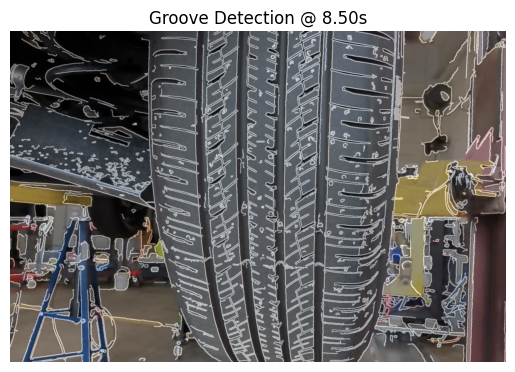

[9.00s]  Groove spacing: 7.91 px → Estimated depth: 0.16 cm


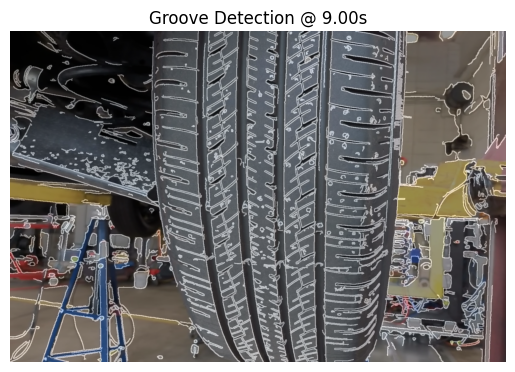

[9.50s]  Groove spacing: 5.79 px → Estimated depth: 0.12 cm


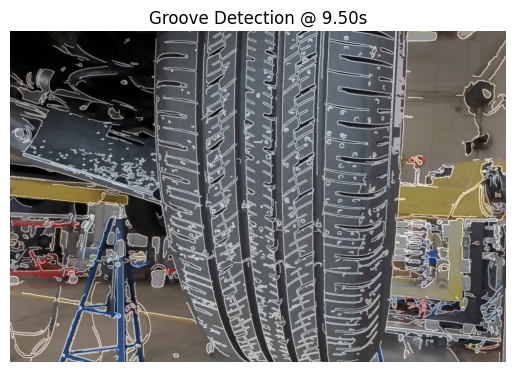

[10.00s]  Groove spacing: 5.33 px → Estimated depth: 0.11 cm


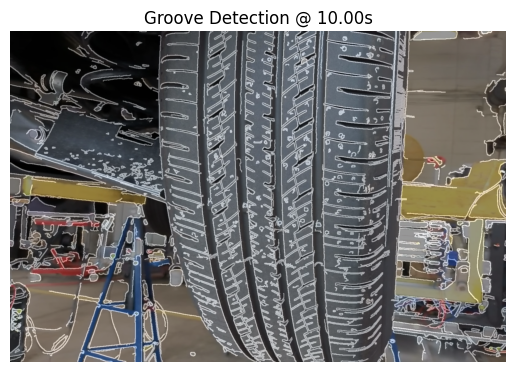

[10.50s]  Groove spacing: 5.33 px → Estimated depth: 0.11 cm


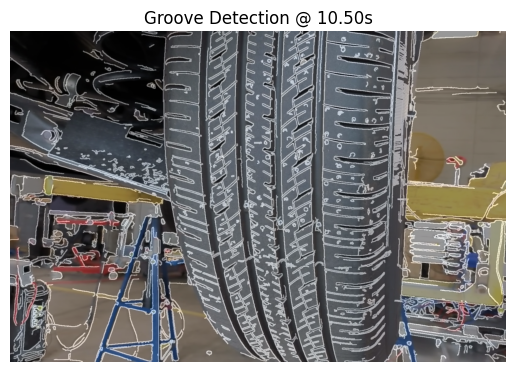

[11.00s]  Groove spacing: 5.24 px → Estimated depth: 0.10 cm


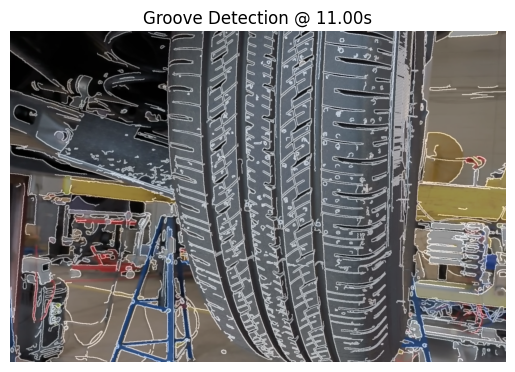

[11.50s]  Groove spacing: 5.05 px → Estimated depth: 0.10 cm


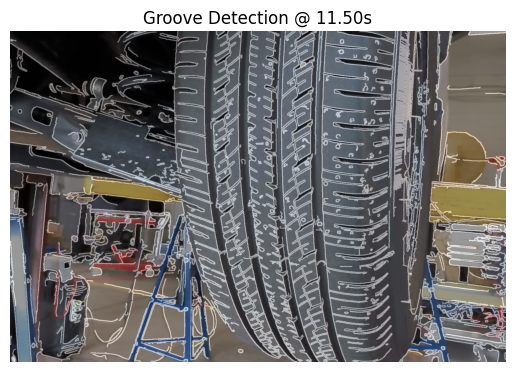

[12.00s]  Groove spacing: 5.19 px → Estimated depth: 0.10 cm


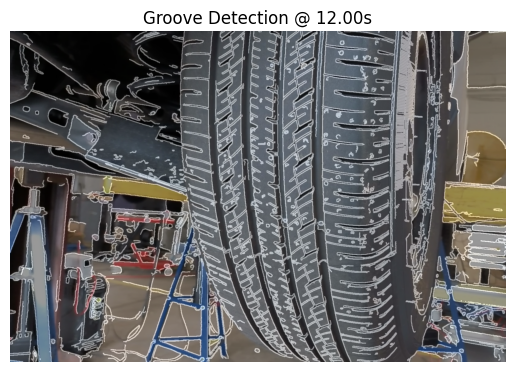

[12.50s]  Groove spacing: 5.29 px → Estimated depth: 0.11 cm


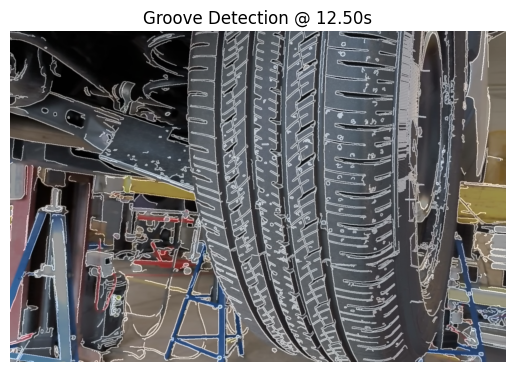

[13.00s]  Groove spacing: 4.95 px → Estimated depth: 0.10 cm


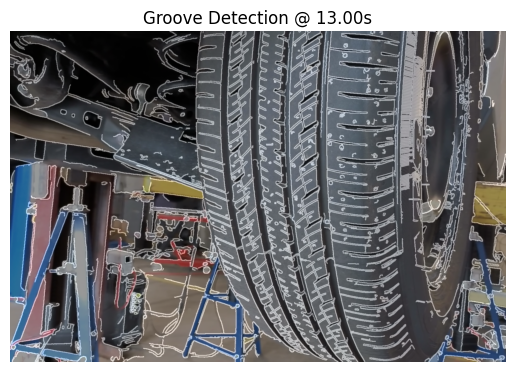

[13.50s]  Groove spacing: 5.50 px → Estimated depth: 0.11 cm


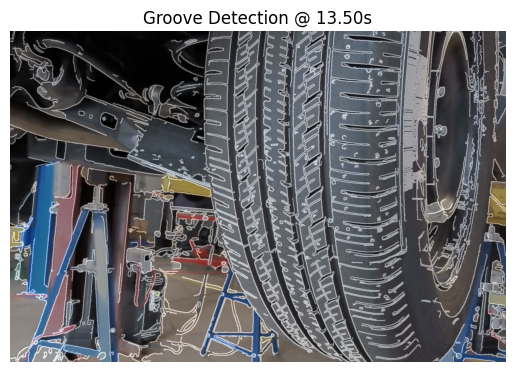

[14.00s]  Groove spacing: 3.70 px → Estimated depth: 0.07 cm


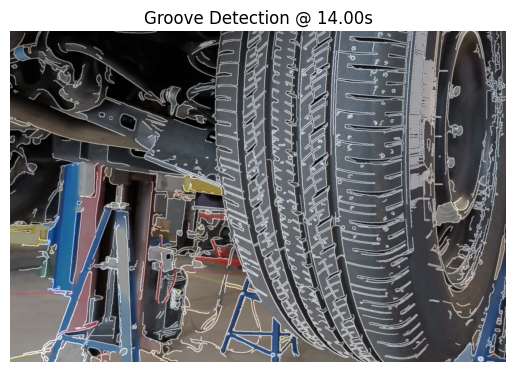

[14.50s]  Groove spacing: 3.98 px → Estimated depth: 0.08 cm


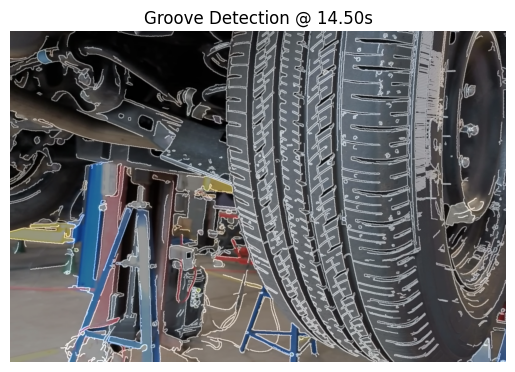

[15.00s]  Groove spacing: 4.36 px → Estimated depth: 0.09 cm


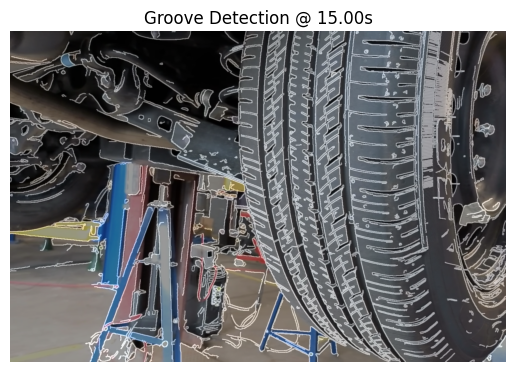

[15.50s]  Groove spacing: 3.66 px → Estimated depth: 0.07 cm


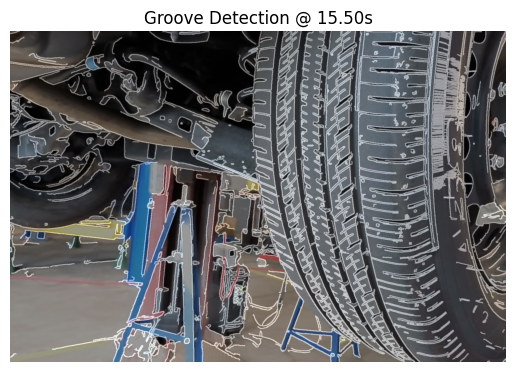

[16.00s]  Groove spacing: 4.77 px → Estimated depth: 0.10 cm


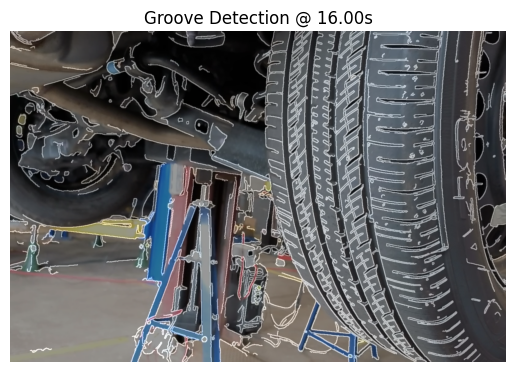

[16.50s]  Groove spacing: 5.58 px → Estimated depth: 0.11 cm


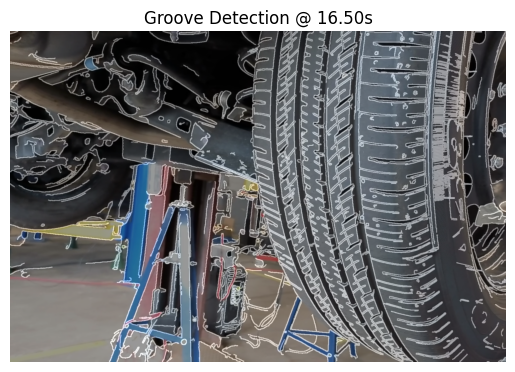

[17.00s]  Groove spacing: 5.90 px → Estimated depth: 0.12 cm


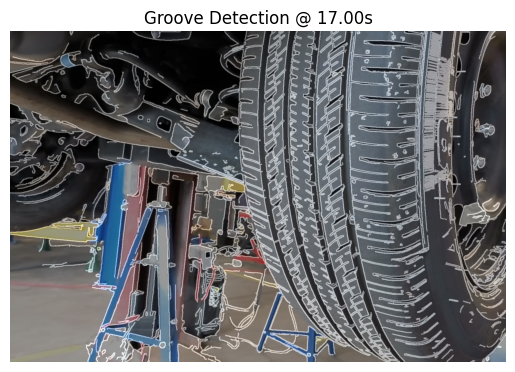

[17.50s]  Groove spacing: 3.96 px → Estimated depth: 0.08 cm


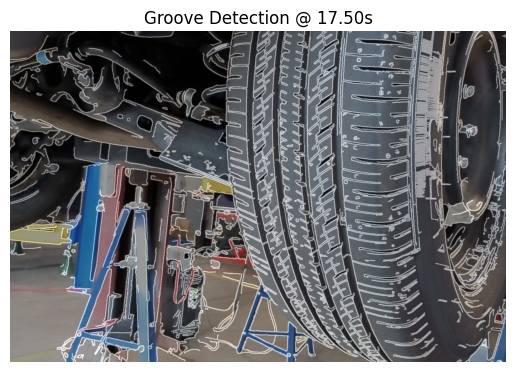


📊 Groove Summary Across All Frames
Average groove spacing: 5.95 px
Average estimated depth: 0.12 cm


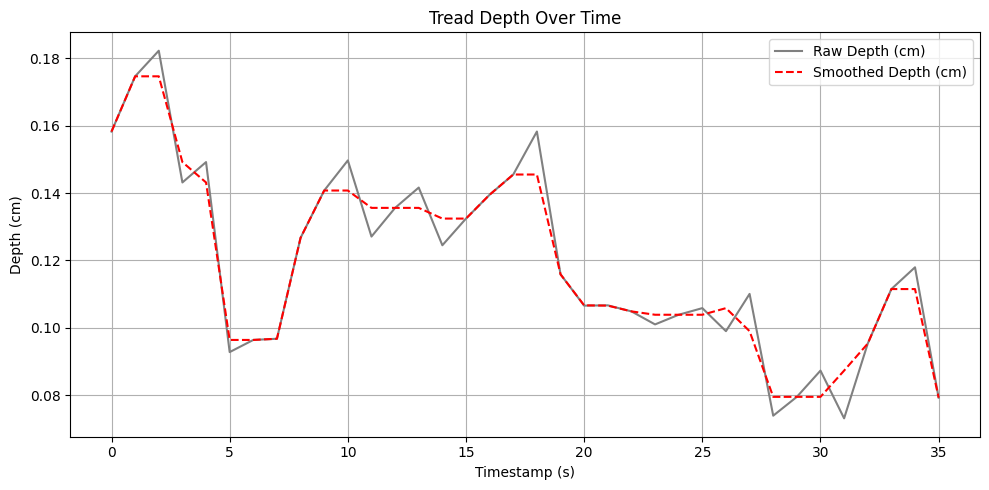

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.ndimage import median_filter

# ---------------------- CONFIG ----------------------
VIDEO_PATH = "Tire Pan 2.mp4"
CM_PER_PIXEL = 0.02  # Calibrate based on known reference
FRAME_STEP_SEC = 0.5  # Sample every 0.5 seconds
OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------- FRAME EXTRACTION ----------------------
def get_video_duration(video_path):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()
    return frame_count / fps

def extract_frame(video_path, timestamp_sec):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_number = int(fps * timestamp_sec)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap.read()
    cap.release()
    return frame if ret else None

# ---------------------- PREPROCESSING ----------------------
def preprocess(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(blur)
    return enhanced

# ---------------------- GROOVE DETECTION ----------------------
def detect_grooves(image):
    edges = cv2.Canny(image, 50, 150)
    kernel = np.ones((3,3), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=1)
    return dilated

# ---------------------- DEPTH ESTIMATION ----------------------
def estimate_groove_depth(binary_image, cm_per_pixel=0.02):
    vertical_sum = np.sum(binary_image, axis=0)
    peaks = np.where(vertical_sum > np.percentile(vertical_sum, 90))[0]
    if len(peaks) < 2:
        return None, None
    spacings = np.diff(peaks)
    avg_spacing_px = np.mean(spacings)
    estimated_depth_cm = avg_spacing_px * cm_per_pixel
    return avg_spacing_px, estimated_depth_cm

# ---------------------- VISUALIZATION ----------------------
def visualize(frame, grooves, timestamp):
    overlay = cv2.addWeighted(frame, 0.6, cv2.cvtColor(grooves, cv2.COLOR_GRAY2BGR), 0.4, 0)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"Groove Detection @ {timestamp:.2f}s")
    plt.axis('off')
    plt.show()

def plot_depths(raw_depths, smoothed_depths):
    plt.figure(figsize=(10, 5))
    plt.plot(raw_depths, label="Raw Depth (cm)", color='gray')
    plt.plot(smoothed_depths, label="Smoothed Depth (cm)", linestyle='--', color='red')
    plt.title("Tread Depth Over Time")
    plt.xlabel("Timestamp (s)")
    plt.ylabel("Depth (cm)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/depth_profile.png")
    plt.show()

# ---------------------- MAIN PIPELINE ----------------------
def main():
    duration = get_video_duration(VIDEO_PATH)
    timestamps = np.arange(0, duration, FRAME_STEP_SEC)

    measured_depths = []
    all_spacings = []

    for t in timestamps:
        frame = extract_frame(VIDEO_PATH, t)
        if frame is None:
            print(f"[{t:.2f}s]  Frame extraction failed.")
            measured_depths.append(np.nan)
            continue

        processed = preprocess(frame)
        grooves = detect_grooves(processed)
        spacing_px, depth_cm = estimate_groove_depth(grooves, CM_PER_PIXEL)

        if spacing_px:
            print(f"[{t:.2f}s]  Groove spacing: {spacing_px:.2f} px → Estimated depth: {depth_cm:.2f} cm")
            measured_depths.append(depth_cm)
            all_spacings.append(spacing_px)
        else:
            print(f"[{t:.2f}s]  Groove detection failed or insufficient data.")
            measured_depths.append(np.nan)

        visualize(frame, grooves, t)

    smoothed_depths = median_filter(measured_depths, size=3)

    valid_depths = [d for d in measured_depths if not np.isnan(d)]
    valid_spacings = [s for s in all_spacings if not np.isnan(s)]

    if valid_depths:
        avg_spacing = np.mean(valid_spacings)
        avg_depth = np.mean(valid_depths)
        print("\n📊 Groove Summary Across All Frames")
        print(f"Average groove spacing: {avg_spacing:.2f} px")
        print(f"Average estimated depth: {avg_depth:.2f} cm")
    else:
        print("\n! No valid groove detections to summarize.")

    plot_depths(measured_depths, smoothed_depths)

if __name__ == "__main__":
    main()


In [47]:
import cv2
import torch
import torch.nn as nn
from torchvision.transforms import Compose
from midas.dpt_depth import DPTDepthModel
from midas.transforms import Resize, NormalizeImage, PrepareForNet
import re

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create model
midas = DPTDepthModel(backbone="beitl16_384", non_negative=True)

# Load checkpoint safely (cpu first)
ckpt_path = "MiDas/weights/dpt_beit_large_384.pt"
ckpt = torch.load(ckpt_path, map_location="cpu")
if isinstance(ckpt, dict) and "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
else:
    state_dict = ckpt

# Filter out keys that are metadata / not expected by model
model_state = midas.state_dict()
filtered_state = {}
removed_keys = []
for k, v in state_dict.items():
    # remove keys that are clearly not parameters (relative position indices, indices, or other metadata)
    if re.search(r"relative_position_index|relative_position_bias_table|attn.relative_position_index|index", k):
        removed_keys.append(k)
        continue
    if k in model_state:
        filtered_state[k] = v
    else:
        removed_keys.append(k)

print(f"[checkpoint] total keys: {len(state_dict)}, kept: {len(filtered_state)}, removed: {len(removed_keys)}")
if removed_keys:
    # print a few removed keys so you can inspect
    for k in removed_keys[:30]:
        print(" removed:", k)

# Load filtered dict (strict=False to allow missing keys)
midas.load_state_dict(filtered_state, strict=False)

# Patch missing drop_path (no-op) on transformer blocks to avoid AttributeError during forward
def patch_drop_path(model):
    patched = 0
    # Try common path midas.pretrained.model.blocks
    try:
        if hasattr(model, "pretrained") and hasattr(model.pretrained, "model") and hasattr(model.pretrained.model, "blocks"):
            for blk in model.pretrained.model.blocks:
                if not hasattr(blk, "drop_path"):
                    blk.drop_path = nn.Identity()
                    patched += 1
    except Exception:
        pass

    # fallback: scan modules heuristically (modules with 'attn' attr but no drop_path)
    for m in model.modules():
        if hasattr(m, "attn") and not hasattr(m, "drop_path"):
            m.drop_path = nn.Identity()
            patched += 1

    print(f"[patch_drop_path] patched {patched} modules (added drop_path=Identity).")

patch_drop_path(midas)

# Move model to device and set eval
midas.to(device)
midas.eval()

# Define transform (ensure cv2 is imported)
transform = Compose([
    Resize(384, 384, resize_target=None, keep_aspect_ratio=True,
           ensure_multiple_of=32, resize_method="minimal", image_interpolation_method=cv2.INTER_CUBIC),
    NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    PrepareForNet()
])

print("Model loaded and patched; ready for inference on", device)


[checkpoint] total keys: 487, kept: 439, removed: 48
 removed: pretrained.model.blocks.0.attn.relative_position_bias_table
 removed: pretrained.model.blocks.0.attn.relative_position_index
 removed: pretrained.model.blocks.1.attn.relative_position_bias_table
 removed: pretrained.model.blocks.1.attn.relative_position_index
 removed: pretrained.model.blocks.2.attn.relative_position_bias_table
 removed: pretrained.model.blocks.2.attn.relative_position_index
 removed: pretrained.model.blocks.3.attn.relative_position_bias_table
 removed: pretrained.model.blocks.3.attn.relative_position_index
 removed: pretrained.model.blocks.4.attn.relative_position_bias_table
 removed: pretrained.model.blocks.4.attn.relative_position_index
 removed: pretrained.model.blocks.5.attn.relative_position_bias_table
 removed: pretrained.model.blocks.5.attn.relative_position_index
 removed: pretrained.model.blocks.6.attn.relative_position_bias_table
 removed: pretrained.model.blocks.6.attn.relative_position_index
 r

In [48]:
frame = extract_frame(video_path, t)
depth_map = estimate_midas_depth(frame, transform, midas, device)

# Normalize depth map to range [0, 1]
normalized = (depth_map - np.min(depth_map)) / (np.max(depth_map) - np.min(depth_map) + 1e-6)

# Sample central region of the normalized depth map
h, w = normalized.shape
roi = normalized[h//3:2*h//3, w//4:3*w//4]
avg_depth = np.mean(roi)

# Print normalized depth value with context
print(f"[{t:.2f}s]  Avg normalized depth: {avg_depth:.4f} (unitless, relative scale from MiDaS)")


[17.00s]  Avg normalized depth: 0.5188 (unitless, relative scale from MiDaS)


In [49]:
import cv2
import torch
import numpy as np
import os
import csv

# ----------- CONFIG -----------
VIDEO_PATH = "Tire Pan 2.mp4"
FRAME_STEP_SEC = 0.5
OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ----------- UTILS -----------
def get_video_duration(video_path):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()
    return frame_count / fps

def extract_frame(video_path, timestamp_sec):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_number = int(fps * timestamp_sec)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap.read()
    cap.release()
    return frame if ret else None

def estimate_midas_depth(frame, transform, midas, device):
    input_image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    data = transform({"image": input_image})
    transformed = data["image"]
    if isinstance(transformed, np.ndarray):
        if transformed.ndim == 3 and transformed.shape[2] in (1, 3):
            transformed = np.transpose(transformed, (2, 0, 1))
        tensor = torch.from_numpy(transformed).unsqueeze(0)
    else:
        tensor = transformed.unsqueeze(0)
    tensor = tensor.to(device=device, dtype=torch.float32).contiguous()
    with torch.no_grad():
        pred = midas(tensor)
        if pred.dim() == 4 and pred.shape[1] == 1:
            depth_map = pred.squeeze(1).squeeze(0).cpu().numpy()
        else:
            depth_map = pred.squeeze().cpu().numpy()
    return depth_map

def smooth_signal_nan_aware(signal, k=3):
    arr = np.array(signal, dtype=np.float32)
    n = len(arr)
    inds = np.arange(n)
    valid_mask = ~np.isnan(arr)
    if not valid_mask.any():
        return arr
    arr_interp = np.copy(arr)
    arr_interp[~valid_mask] = np.interp(inds[~valid_mask], inds[valid_mask], arr[valid_mask])
    arr2d = arr_interp.reshape(-1, 1)
    smoothed2d = cv2.blur(arr2d, (k, 1)).flatten()
    return smoothed2d

def write_depth_csv(timestamps, depths, out_path, smoothed=None, confidence=None, units="unitless"):
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    t = np.asarray(timestamps, dtype=float)
    d = np.asarray(depths, dtype=float)
    s = np.asarray(smoothed, dtype=float) if smoothed is not None else None
    c = np.asarray(confidence, dtype=float) if confidence is not None else None
    headers = ["time_s", f"depth_{units}"]
    if s is not None:
        headers.append(f"depth_{units}_smoothed")
    if c is not None:
        headers.append("confidence")
    with open(out_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        for i in range(len(t)):
            row = [f"{t[i]:.3f}", f"{d[i]:.6f}"]
            if s is not None:
                row.append(f"{s[i]:.6f}")
            if c is not None:
                row.append(f"{c[i]:.4f}")
            writer.writerow(row)
    print(f"[csv] Wrote {len(t)} rows → {out_path}")

# ----------- MAIN PIPELINE -----------
def run_depth_pipeline(video_path, transform, midas, device):
    duration = get_video_duration(video_path)
    timestamps = np.arange(0, duration, FRAME_STEP_SEC)
    depth_signals = []
    for t in timestamps:
        frame = extract_frame(video_path, t)
        if frame is None:
            print(f"[{t:.2f}s] ❌ Frame extraction failed.")
            depth_signals.append(np.nan)
            continue
        depth_map = estimate_midas_depth(frame, transform, midas, device)
        normalized = (depth_map - np.min(depth_map)) / (np.max(depth_map) - np.min(depth_map) + 1e-6)
        h, w = normalized.shape
        roi = normalized[h//3:2*h//3, w//4:3*w//4]
        avg_depth = np.mean(roi)
        depth_signals.append(avg_depth)
        print(f"[{t:.2f}s]  Avg normalized depth: {avg_depth:.4f} (unitless, relative scale from MiDaS)")

    smoothed = smooth_signal_nan_aware(depth_signals, k=3)
    out_csv = os.path.join(OUTPUT_DIR, "depth_over_time_normalized.csv")
    write_depth_csv(timestamps, depth_signals, out_csv, smoothed=smoothed, confidence=None, units="unitless")

